In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load your crop disease model
model = load_model('/content/drive/MyDrive/CNN-Crop-Disease/model.h5')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 3)    │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ root (Dense)                    │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,308,965 (27.88 MB)

 Trainable params: 7,222,755 (27.55 MB)

 Non-trainable params: 86,208 (336.75 KB)

 Optimizer params: 2 (12.00 B)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Standard preprocessing for crop disease datasets
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(
    'path_to_test_images',
    target_size=(128, 128), # Match the training target size
    batch_size=32,
    class_mode='categorical'
)


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_test_images'

In [8]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/CNN-Crop-Disease/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
# Verify Kaggle API authentication
!kaggle whoami

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,benchmarks,b,config,auth}
              ...
kaggle: error: argument command: invalid choice: 'whoami' (choose from competitions, c, datasets, d, kernels, k, models, m, files, f, benchmarks, b, config, auth)


In [10]:
!kaggle kernels pull byme86/crop-disease-detection-cnn

Source code downloaded to /content/crop-disease-detection-cnn.ipynb


In [11]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:07<00:00, 90.2MB/s]



In [12]:
import zipfile

with zipfile.ZipFile("/content/plantdisease.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [13]:
import os

os.listdir("dataset")

['PlantVillage', 'plantvillage']

In [14]:
dataset_path = "dataset/PlantVillage"

classes = os.listdir(dataset_path)

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 15
['Tomato_healthy', 'Potato___Late_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Potato___Early_blight', 'Pepper__bell___Bacterial_spot', 'Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_Early_blight']


In [15]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/CNN-Crop-Disease/model.h5", compile=False)

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_generator = test_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 4122 images belonging to 15 classes.


In [18]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.6633 - loss: 1.6581
Test Loss: 1.6580915451049805
Test Accuracy: 0.6632702350616455


In [21]:
print(test_generator.class_indices)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [23]:
import numpy as np
from sklearn.metrics import classification_report

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

129/129 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.87      0.79      0.83       199
                     Pepper__bell___healthy       0.52      0.46      0.49       295
                      Potato___Early_blight       0.63      0.96      0.76       200
                       Potato___Late_blight       0.75      0.73      0.74       200
                           Potato___healthy       0.09      0.97      0.17        30
                      Tomato_Bacterial_spot       0.94      0.75      0.83       425
                        Tomato_Early_blight       0.70      0.76      0.73       200
                         Tomato_Late_blight       0.54      0.84      0.66       381
                           Tomato_Leaf_Mold       0.99      0.41      0.58       190
                  Tomato_Septoria_leaf_spot       0.65      0.80      0.72       354
Tomato_Spider_mites_Tw

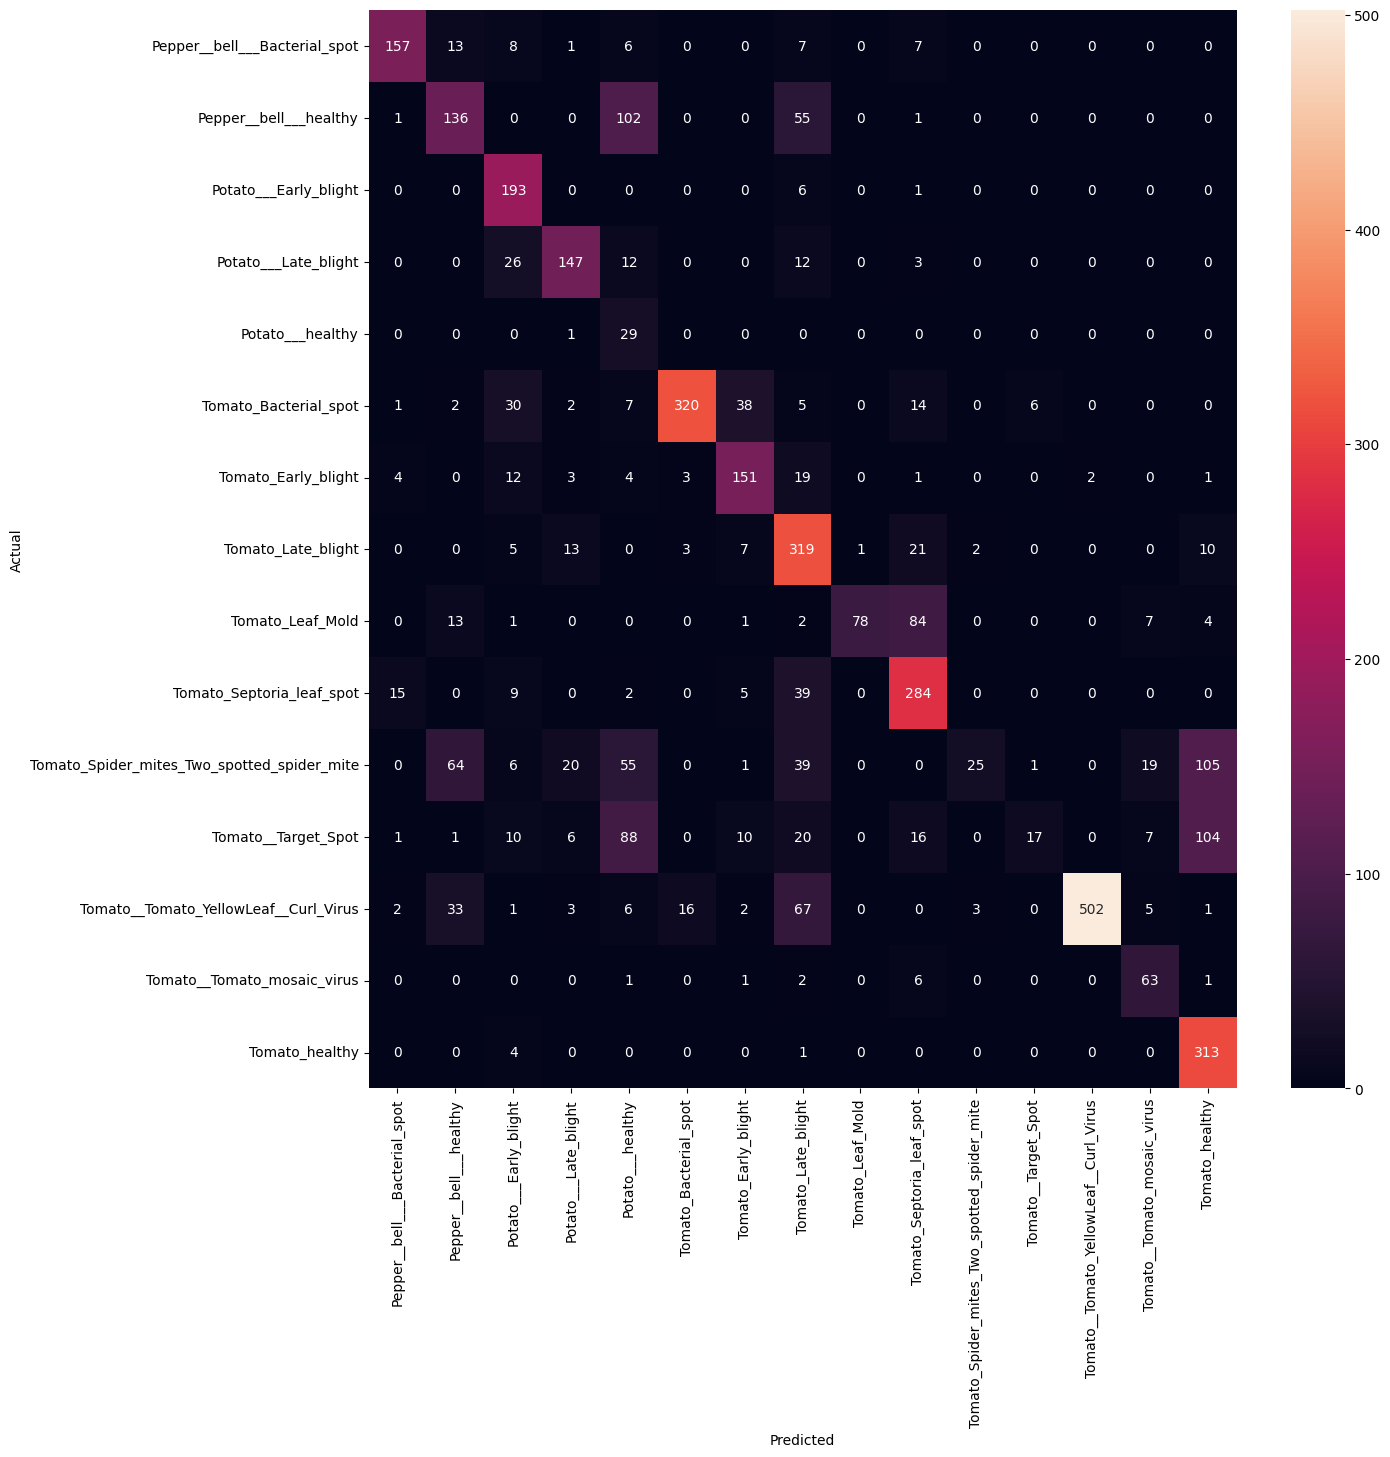

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(14,14))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/drive/MyDrive/CNN-Crop-Disease/leaf.jpg",
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

print("Predicted Disease:", class_labels[predicted_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Predicted Disease: Pepper__bell___Bacterial_spot


In [27]:
model.save("plant_disease_classifier.keras")